In [ ]:
pip install matplotlib seaborn pandas kagglehub

In [6]:
import pandas as pd
import json
import kagglehub
import os
import shutil
import math
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

/home/rafihaqul/project/LDXray/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Load

In [2]:
# Download latest version
path = kagglehub.dataset_download("yuzheguocs/ldxray")

print("Path to dataset files:", path)

Path to dataset files: /home/rafihaqul/.cache/kagglehub/datasets/yuzheguocs/ldxray/versions/3


In [3]:
with open(path + '/test.json', 'r') as f:
    data_test = json.load(f)

images_test = data_test['images']
annotations_test = data_test['annotations']

```bash
dataset/
├── images/
│    ├── test/
│    │    ├── name1.jpg
│    │    ├── name2.jpg
│    │    └── name3.jpg
│    │        ...
│    └── test/
│        ├── name1.jpg
│        ├── name2.jpg
│        └── name3.jpg
│            ...
└── labels/
    ├── test/
    │    ├── name1.txt >> id_cat | bbox
    │    ├── name2.txt >> id_cat | bbox
    │    └── name3.txt >> id_cat | bbox
    │        ...
    └── test/
        ├── name1.txt >> id_cat | bbox
        ├── name2.txt >> id_cat | bbox
        └── name3.txt >> id_cat | bbox
            ...

data.yaml >>    test: dataset/images/train
                val: dataset/images/val
                test: dataset/images/test

                nc: 2
                names: ["Laptop", "Mobile_Phone", ...]
```

# LABELS

In [6]:
# Dict: image_id → file_name (tanpa ekstensi untuk nama file .txt)
id_to_filename = {
    img["id"]: os.path.splitext(img["file_name"])[0]
    for img in images_test
}

# Contoh hasil mapping
sample = list(id_to_filename.items())[:3]
print("Contoh mapping:")
for k, v in sample:
    print(f"  image_id={k}  →  {v}.txt")

# Kita butuh dimensi gambar untuk normalisasi koordinat
id_to_size = {
    img["id"]: (img["width"], img["height"])
    for img in images_test
}

# Contoh
sample = list(id_to_size.items())[:3]
print("Contoh dimensi gambar:")
for img_id, (w, h) in sample:
    print(f"  image_id={img_id}  →  w={w}, h={h}")

Contoh mapping:
  image_id=1  →  000000.txt
  image_id=2  →  000001.txt
  image_id=3  →  000002.txt
Contoh dimensi gambar:
  image_id=1  →  w=440, h=1040
  image_id=2  →  w=436, h=1040
  image_id=3  →  w=504, h=1040


In [7]:
from collections import defaultdict

ann_per_image = defaultdict(list)

for ann in annotations_test:
    img_id      = ann["image_id"]
    category_id = ann["category_id"]
    bbox        = ann["bbox"]      # [x_min, y_min, width, height] COCO
    ann_per_image[img_id].append({
        "category_id": category_id,
        "bbox": bbox
    })

print(f"Images yang memiliki anotasi: {len(ann_per_image)}")

Images yang memiliki anotasi: 36407


In [8]:
output_dir = "../data/interim/test_labels"
os.makedirs(output_dir, exist_ok=True)

skipped_img   = 0   # gambar tidak ditemukan di id_to_filename
skipped_ann   = 0   # anotasi dengan koordinat tidak valid
written_files = 0

for img_id, anns in ann_per_image.items():
    filename = id_to_filename.get(img_id)
    img_size = id_to_size.get(img_id)

    if not filename or not img_size:
        skipped_img += 1
        continue

    img_w, img_h = img_size
    out_path = os.path.join(output_dir, f"{filename}.txt")
    lines = []

    for ann in anns:
        # ── Konversi 1: category_id dari 1-based → 0-based ──────────────
        class_id = ann["category_id"] - 1

        # ── Konversi 2: COCO [x_min,y_min,w,h] → center x,y ────────────
        x_min, y_min, bw, bh = ann["bbox"]
        cx = x_min + bw / 2
        cy = y_min + bh / 2

        # ── Konversi 3: normalisasi ke rentang 0–1 ───────────────────────
        cx_n = cx / img_w
        cy_n = cy / img_h
        bw_n = bw / img_w
        bh_n = bh / img_h

        # ── Validasi: buang bbox yang keluar batas gambar ───────────────
        if not (0 <= cx_n <= 1 and 0 <= cy_n <= 1 and
                0 < bw_n <= 1 and 0 < bh_n <= 1):
            skipped_ann += 1
            continue

        lines.append(f"{class_id} {cx_n:.6f} {cy_n:.6f} {bw_n:.6f} {bh_n:.6f}")

    # Tulis file hanya jika ada anotasi valid
    if lines:
        with open(out_path, "w") as f:
            f.write("\n".join(lines))
        written_files += 1

print(f"File label ditulis    : {written_files}")
print(f"Gambar dilewati       : {skipped_img}")
print(f"Anotasi out-of-bounds : {skipped_ann}")

File label ditulis    : 36404
Gambar dilewati       : 0
Anotasi out-of-bounds : 9


In [12]:
sample_files = os.listdir(output_dir)[:1]

for fname in sample_files:
    fpath = os.path.join(output_dir, fname)

    print(f"=== {fname} ===")
    with open(fpath) as f:
        for line in f:
            parts = line.strip().split()
            cls, cx, cy, w, h = parts
            ok = "✅" if all(0 <= float(v) <= 1 for v in [cx,cy,w,h]) else "❌"
            print(f"  {ok} class={cls} cx={cx} cy={cy} w={w} h={h}")

# Contoh output yang benar:
# ✅ class=0 cx=0.552083 cy=0.812500 w=0.108333 h=0.256944

=== 031886.txt ===
  ✅ class=4 cx=0.154018 cy=0.735096 w=0.089286 h=0.054808


# IMAGES

In [ ]:
# output_dir = "../data/interim/images"
# source_img_dirA = path + "/dataset/test_A"
# source_img_dirB = path + "/dataset/test_B"

# os.makedirs(output_dir, exist_ok=True)

# # Iterasi dan salin setiap file
# for source_dir in [source_img_dirA, source_img_dirB]:
#     for filename in os.listdir(source_dir):
#         source_file = os.path.join(source_dir, filename)

#         # Pastikan yang disalin adalah file, bukan folder
#         if os.path.isfile(source_file):
#             shutil.copy2(source_file, output_dir) # copy2() menyalin metadata (waktu modifikasi, dll)
#     print(f"Selesai menyalin dari {source_dir} ke {output_dir}")

In [13]:
output_dir = "../data/interim/test_images"
source_img_dir = path + "/dataset/test_A"

os.makedirs(output_dir, exist_ok=True)

# Iterasi dan salin setiap file
for source_dir in [source_img_dir]:
    for filename in os.listdir(source_dir):
        source_file = os.path.join(source_dir, filename)

        # Pastikan yang disalin adalah file, bukan folder
        if os.path.isfile(source_file):
            shutil.copy2(source_file, output_dir) # copy2() menyalin metadata (waktu modifikasi, dll)
    print(f"Selesai menyalin dari {source_dir} ke {output_dir}")

Selesai menyalin dari /home/rafihaqul/.cache/kagglehub/datasets/yuzheguocs/ldxray/versions/3/dataset/test_A ke ../data/interim/test_images


# DATA SPLIT

In [14]:
# ── Konfigurasi path sumber ───────────────────────────────────────────
src_images = "../data/interim/test_images"        # folder berisi file .jpg
src_labels = "../data/interim/test_labels"        # folder berisi file .txt

# ── Konfigurasi path tujuan ───────────────────────────────────────────
dst_val_images   = "../data/processed/images/val/"
dst_val_labels   = "../data/processed/labels/val/"
dst_test_images = "../data/processed/images/test/"
dst_test_labels = "../data/processed/labels/test/"

# ── Rasio split ───────────────────────────────────────────────────────
test_ratio = 0.5
val_ratio   = 1 - test_ratio

In [15]:
# Periksa apakah folder sumber ada
for d in [dst_test_images, dst_test_labels, dst_val_images, dst_val_labels]:
    os.makedirs(d, exist_ok=True)

print("Folder tujuan siap:")
print(f"  {dst_test_images}")
print(f"  {dst_test_labels}")
print(f"  {dst_val_images}")
print(f"  {dst_val_labels}")

Folder tujuan siap:
  ../data/processed/images/test/
  ../data/processed/labels/test/
  ../data/processed/images/val/
  ../data/processed/labels/val/


In [16]:
# Ambil nama file gambar yang punya pasangan label, urutkan secara natural
all_images = sorted([
    f for f in os.listdir(src_images)
    if f.lower().endswith(".jpg")
])

# Filter: hanya proses gambar yang punya label pasangan
paired = []
for img_file in all_images:
    stem = os.path.splitext(img_file)[0]
    if os.path.exists(os.path.join(src_labels, stem + ".txt")):
        paired.append(stem)

total      = len(paired)
n_test    = math.floor(total * test_ratio)
n_val      = math.floor(total * val_ratio)

print(f"Total pasangan gambar+label : {total}")
print(f"Valid                      : {n_val}")
print(f"test                      : {n_test}")
print(f"Sisa                       : {total - n_test - n_val}")

Total pasangan gambar+label : 36404
Valid                      : 18202
test                      : 18202
Sisa                       : 0


In [17]:
def move_pair(stem, dst_img_dir, dst_lbl_dir):
    """Pindahkan satu pasangan .jpg + .txt ke direktori tujuan."""
    src_img = os.path.join(src_images, stem + ".jpg")
    src_lbl = os.path.join(src_labels, stem + ".txt")
    dst_img = os.path.join(dst_img_dir, stem + ".jpg")
    dst_lbl = os.path.join(dst_lbl_dir, stem + ".txt")
    shutil.move(src_img, dst_img)
    shutil.move(src_lbl, dst_lbl)

print("Fungsi move_pair() siap digunakan.")

Fungsi move_pair() siap digunakan.


In [18]:
# Tentukan slice masing-masing split (urutan, tanpa shuffle)
test_stems = paired[:n_test]
val_stems   = paired[n_test : n_test + n_val]

# Pindahkan test
for stem in test_stems:
    move_pair(stem, dst_test_images, dst_test_labels)
print(f"[test] {len(test_stems)} pasangan dipindahkan.")

# Pindahkan valid
for stem in val_stems:
    move_pair(stem, dst_val_images, dst_val_labels)
print(f"[Valid] {len(val_stems)} pasangan dipindahkan.")

[test] 18202 pasangan dipindahkan.
[Valid] 18202 pasangan dipindahkan.


In [19]:
def count_dir(path, ext):
    return len([f for f in os.listdir(path) if f.endswith(ext)])

print("─── Hasil verifikasi ───────────────────────────────")
print(f"  test/images : {count_dir(dst_test_images, '.jpg')} file")
print(f"  test/labels : {count_dir(dst_test_labels, '.txt')} file")
print(f"  valid/images : {count_dir(dst_val_images, '.jpg')} file")
print(f"  valid/labels : {count_dir(dst_val_labels, '.txt')} file")

# Pastikan jumlah images == labels di setiap split
assert count_dir(dst_test_images, '.jpg') == count_dir(dst_test_labels, '.txt'), "Mismatch test!"
assert count_dir(dst_val_images,   '.jpg') == count_dir(dst_val_labels,   '.txt'), "Mismatch valid!"
print("Semua pasangan image-label cocok. Split selesai!")

─── Hasil verifikasi ───────────────────────────────
  test/images : 18202 file
  test/labels : 18202 file
  valid/images : 18202 file
  valid/labels : 18202 file
Semua pasangan image-label cocok. Split selesai!


# Visualitation

In [7]:
# ── Path dataset hasil split ─────────────────────────────────────────
test_img_dir = "../data/processed/images/test/"
test_lbl_dir = "../data/processed/labels/test/"
val_img_dir   = "../data/processed/images/val/"
val_lbl_dir   = "../data/processed/labels/val/"

# ── Mapping category_id → nama label ─────────────────────────────────
# Sesuaikan dengan kategori COCO / dataset kamu
CATEGORIES = {
    0: 'Mobile_Phone',  1: 'Orange_Liquid', 2: 'Charger_Without_Cell',
    3: 'Laptop', 4: 'Green_Liquid', 5 : 'Charger_With_Cell', 6: 'Tablet', 7: 'Blue_Liquid',
    8: 'Cylindrical_Orange_Liquid', 9: 'Nonmetallic_Lighter', 10: 'Umbrella',
    11: 'Cylindrical_Green_Liquid'
}

# Warna per kategori (auto-generate jika kategori banyak)
def get_color(cat_id):
    random.seed(cat_id * 37)
    return (random.random(), random.random(), random.random())

In [8]:
# Fungsi untuk membaca file .txt dan mengembalikan list of dict dengan format:
# { 'category_id': int, 'x': float, 'y': float, 'w': float, 'h': float }
def load_labels(label_path, img_w, img_h):
    """
    Baca label YOLO: class_id cx cy w h (ternormalisasi 0-1)
    Konversi balik ke koordinat pixel untuk digambar.
    """
    annotations = []
    if not os.path.exists(label_path):
        return annotations

    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            class_id        = int(parts[0])
            cx_n, cy_n      = float(parts[1]), float(parts[2])
            bw_n, bh_n      = float(parts[3]), float(parts[4])

            # ── Denormalisasi → pixel ─────────────────────────────────
            cx = cx_n * img_w
            cy = cy_n * img_h
            bw = bw_n * img_w
            bh = bh_n * img_h

            # ── YOLO center → sudut kiri atas (untuk Rectangle) ──────
            x_min = cx - bw / 2
            y_min = cy - bh / 2

            annotations.append({
                "class_id": class_id,
                "x": x_min, "y": y_min,
                "w": bw,    "h": bh
            })
    return annotations

print("Fungsi load_labels() siap.")

Fungsi load_labels() siap.


In [9]:
# Fungsi untuk menampilkan gambar dengan bounding box dan label kategori
def draw_image_with_boxes(ax, img_path, label_path, title):
    img     = Image.open(img_path).convert("RGB")
    img_w, img_h = img.size   # ← ambil dimensi dari gambar langsung

    ax.imshow(img)
    ax.set_title(title, fontsize=9, color="white", pad=4,
                backgroundcolor="#222")
    ax.axis("off")

    # ← sekarang kirim img_w & img_h ke load_labels
    annotations = load_labels(label_path, img_w, img_h)

    for ann in annotations:
        class_id = ann["class_id"]
        x, y, w, h = ann["x"], ann["y"], ann["w"], ann["h"]
        color = get_color(class_id)
        label = CATEGORIES.get(class_id, f"id:{class_id}")

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x, y - 4, label, fontsize=7, color="white",
               bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor="none"))

print("Fungsi draw_image_with_boxes() siap.")

Fungsi draw_image_with_boxes() siap.


In [10]:
# Fungsi untuk sampling beberapa gambar secara acak dari folder
def sample_images(img_dir, n=2):
    files = [f for f in os.listdir(img_dir) if f.lower().endswith(".jpg")]
    return random.sample(files, min(n, len(files)))

test_samples = sample_images(test_img_dir, n=2)
val_samples   = sample_images(val_img_dir,   n=2)

print("Sample test :", test_samples)
print("Sample valid :", val_samples)

Sample test : ['016241.jpg', '000542.jpg']
Sample valid : ['020170.jpg', '019060.jpg']


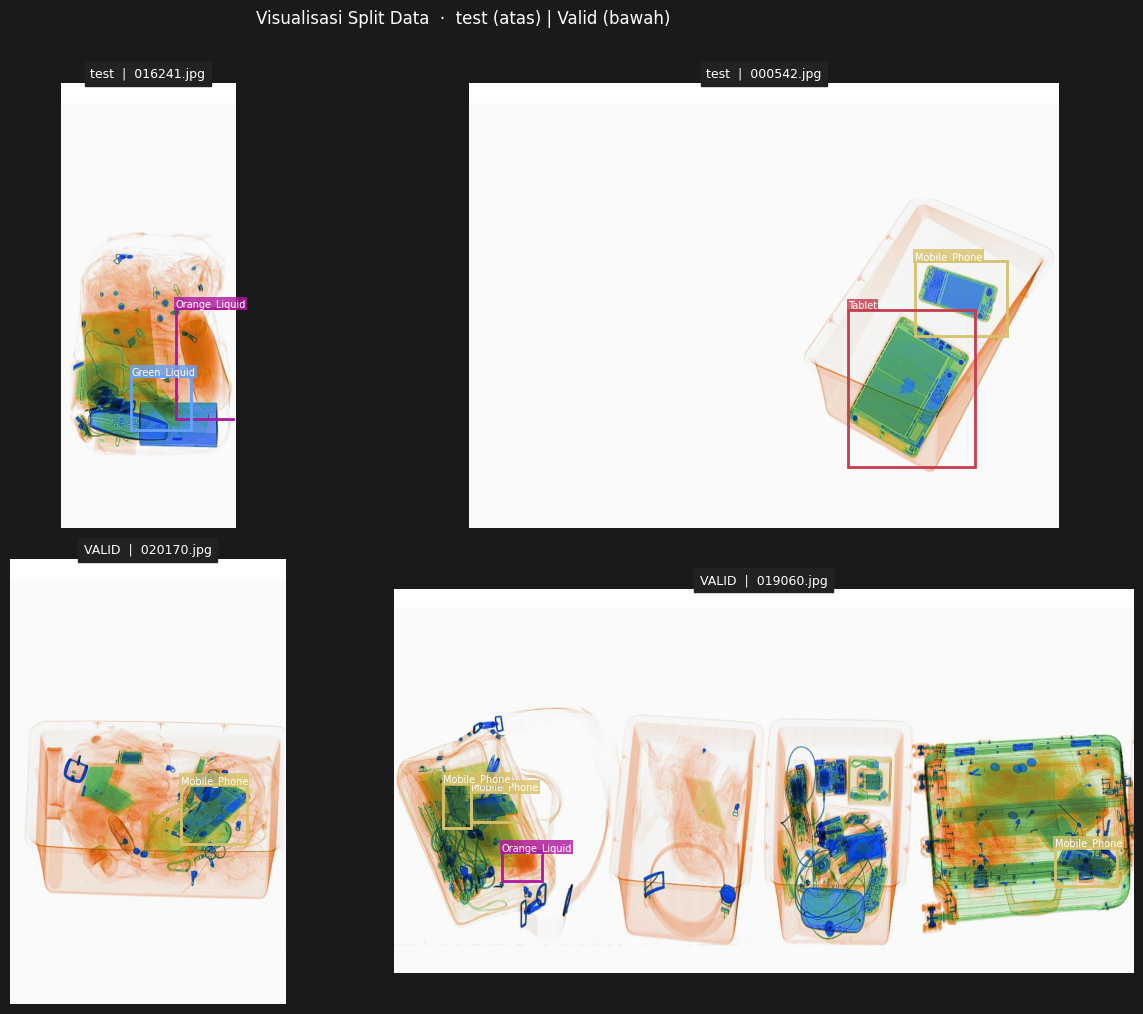

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor("#1a1a1a")
fig.suptitle(
    "Visualisasi Split Data  ·  test (atas) | Valid (bawah)",
    color="white", fontsize=12, y=1.01
)

# ── Baris atas: test ─────────────────────────────────────────────────
for i, fname in enumerate(test_samples):
    stem      = os.path.splitext(fname)[0]
    img_path  = os.path.join(test_img_dir, fname)
    lbl_path  = os.path.join(test_lbl_dir, stem + ".txt")
    draw_image_with_boxes(
        axes[0, i], img_path, lbl_path,
        title=f"test  |  {fname}"
    )

# ── Baris bawah: Valid ────────────────────────────────────────────────
for i, fname in enumerate(val_samples):
    stem      = os.path.splitext(fname)[0]
    img_path  = os.path.join(val_img_dir, fname)
    lbl_path  = os.path.join(val_lbl_dir, stem + ".txt")
    draw_image_with_boxes(
        axes[1, i], img_path, lbl_path,
        title=f"VALID  |  {fname}"
    )

for ax in axes.flat:
    ax.set_facecolor("#2a2a2a")

plt.tight_layout()
# plt.savefig("split_preview.png", dpi=150, bbox_inches="tight",
#             facecolor=fig.get_facecolor())
plt.show()
# print("Tersimpan: split_preview.png")

In [12]:
globals().clear()